# House Price Prediction
## UCI Real Estate Valuation Dataset

This notebook walks through the full machine learning workflow for the first lab dataset: the UCI real estate valuation dataset. The workflow includes:
- importing and loading the dataset
- exploratory data analysis and visualization
- preprocessing and train-test splitting
- baseline regression models
- tree-based and ensemble models
- hyperparameter tuning for selected models
- model evaluation and visualization
- saving the best preprocessing pipeline and model with joblib

### Step 1: Environment setup and Imports

In [46]:
import platform
import json
import os
from datetime import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Fixed seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Print versions for reproducibility
print(f"Python version: {platform.python_version()}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

print("Libraries imported successfully.")

Python version: 3.10.0
NumPy version: 2.2.6
Pandas version: 2.3.2
Matplotlib version: 3.10.6
Seaborn version: 0.13.2
Scikit-learn version: 1.7.2
Libraries imported successfully.


### Step 2: Load the UCI Real Estate Valuation Dataset

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
uci = fetch_ucirepo(id=477)

# Extract features and target variable
X_uci = uci.data.features.copy()
y_uci = uci.data.targets.copy()

# Combine into single DF
df = pd.concat([X_uci, y_uci], axis=1)

# Basic info
print("Dataset shape:", df.shape)
print("\nData sample:\n",df.head(5))
print("\n Dataset metadata: \n", uci.metadata)

Dataset shape: (414, 7)

Data sample:
    X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4 number of convenience stores  X5 latitude  X6 longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y house price of unit area  
0                        37.9  
1                        

### Step 3: Data and target audit

In [5]:
# Define target variable
target = 'Y house price of unit area'

print(f"\nData Audit : ")
print(f"Target variable: '{target}'")
print(f"Target dtype: {df[target].dtype}")

# Comprehensive data audit
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_%': df.isna().mean() * 100,
    'unique_n': df.nunique(dropna=False)
}).sort_values(by='missing_%', ascending=False)

print("\nData Audit (columns with missing values first):")
display(audit.head(20))

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Target variable statistics
print(f"\nTarget variable statistics:")
display(df[target].describe())


Data Audit : 
Target variable: 'Y house price of unit area'
Target dtype: float64

Data Audit (columns with missing values first):


,dtype,missing_n,missing_%,unique_n
X1 transaction date,float64,0,0.0,12
X2 house age,float64,0,0.0,236
X3 distance to the nearest MRT station,float64,0,0.0,259
X4 number of convenience stores,int64,0,0.0,11
X5 latitude,float64,0,0.0,234
X6 longitude,float64,0,0.0,232
Y house price of unit area,float64,0,0.0,270


Duplicate rows: 0

Target variable statistics:


count    414.000000
mean      37.980193
std       13.606488
min        7.600000
25%       27.700000
50%       38.450000
75%       46.600000
max      117.500000
Name: Y house price of unit area, dtype: float64

### Step 4: EDA

Training set shape: (331, 6)
Test set shape: (83, 6)

EXPLORATORY DATA ANALYSIS (on training data only) 


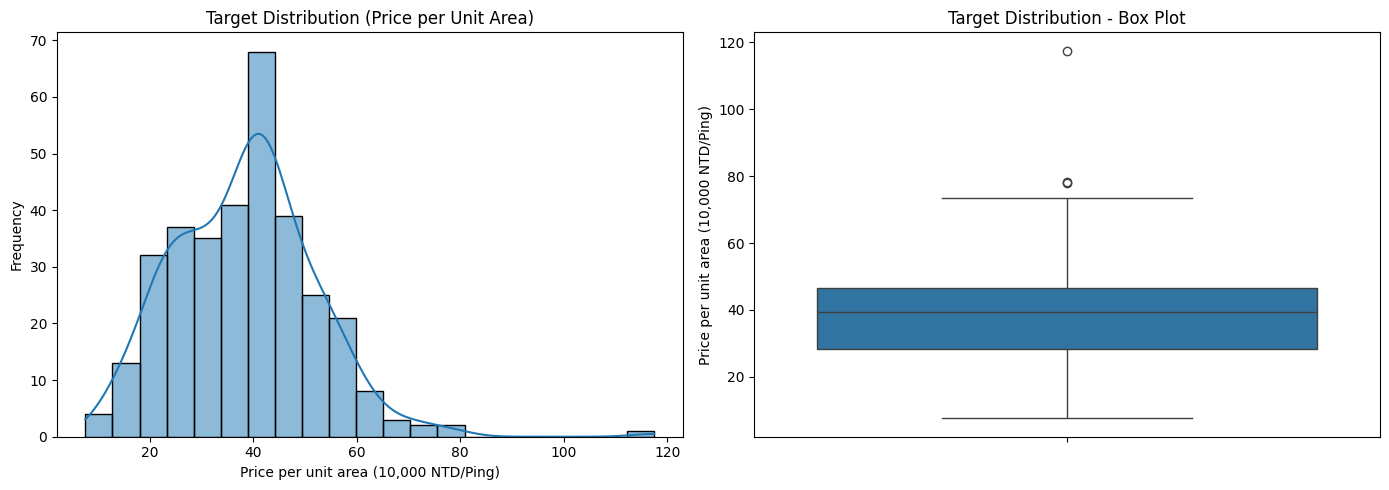

Target skewness: 0.713 (Positive skew suggests log transformation may be beneficial)


In [9]:
# Split data first to prevent any leakage
# Remove identifier columns if any
DROP_COLS = ['No'] if 'No' in df.columns else []
X = df.drop(columns=DROP_COLS + [target])
y = df[target].copy()

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Create a combined training DataFrame for EDA
train_df = X_train.copy()
train_df[target] = y_train

print("\nEXPLORATORY DATA ANALYSIS (on training data only) ")

# Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(train_df[target], kde=True, ax=axes[0])
axes[0].set_title('Target Distribution (Price per Unit Area)')
axes[0].set_xlabel('Price per unit area (10,000 NTD/Ping)')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(y=train_df[target], ax=axes[1])
axes[1].set_title('Target Distribution - Box Plot')
axes[1].set_ylabel('Price per unit area (10,000 NTD/Ping)')

plt.tight_layout()
plt.show()

# Target skewness
skewness = train_df[target].skew()
print(f"Target skewness: {skewness:.3f} (Positive skew suggests log transformation may be beneficial)")

In [10]:
# Missing Value Profile
missing_data = train_df.isna().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    plt.figure(figsize=(10, 5))
    missing_data.plot(kind='bar')
    plt.title('Missing Values by Feature')
    plt.xlabel('Feature')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No missing values in the training data.")

No missing values in the training data.


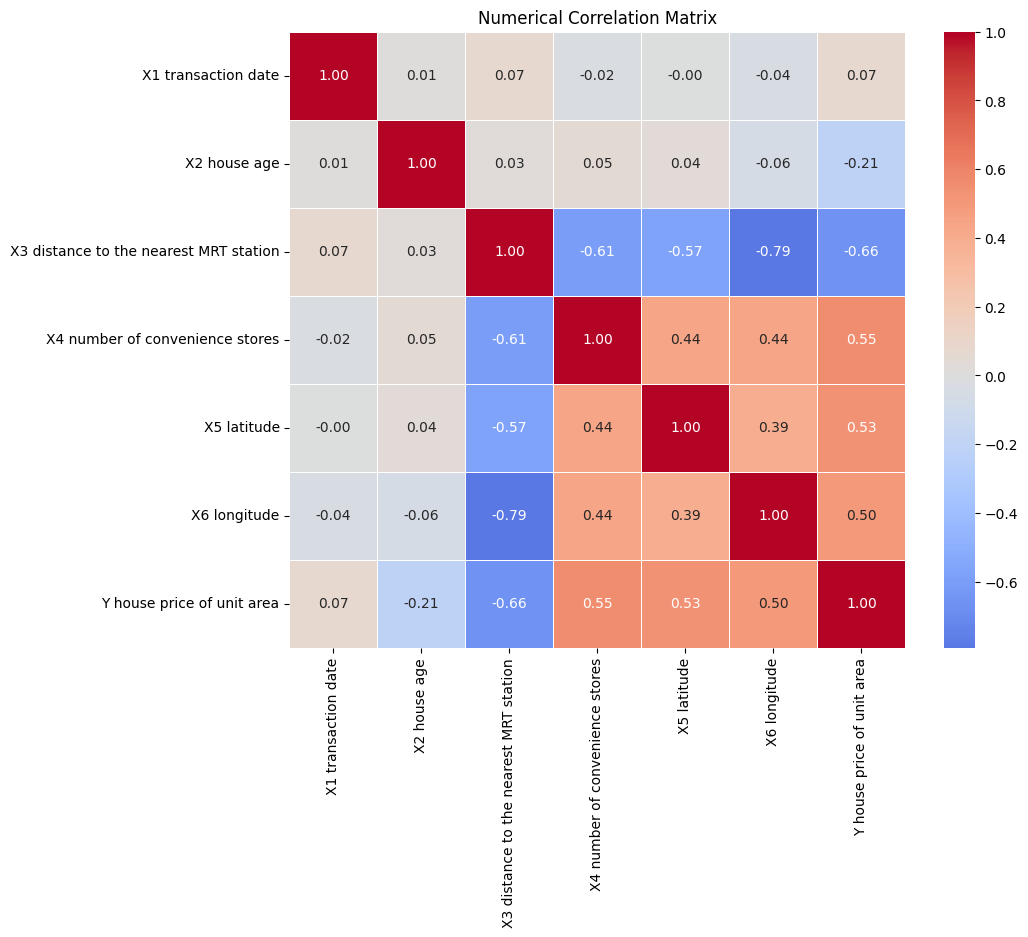

In [11]:
# Numerical Correlation Heatmap
num_df = train_df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Numerical Correlation Matrix')
plt.show()

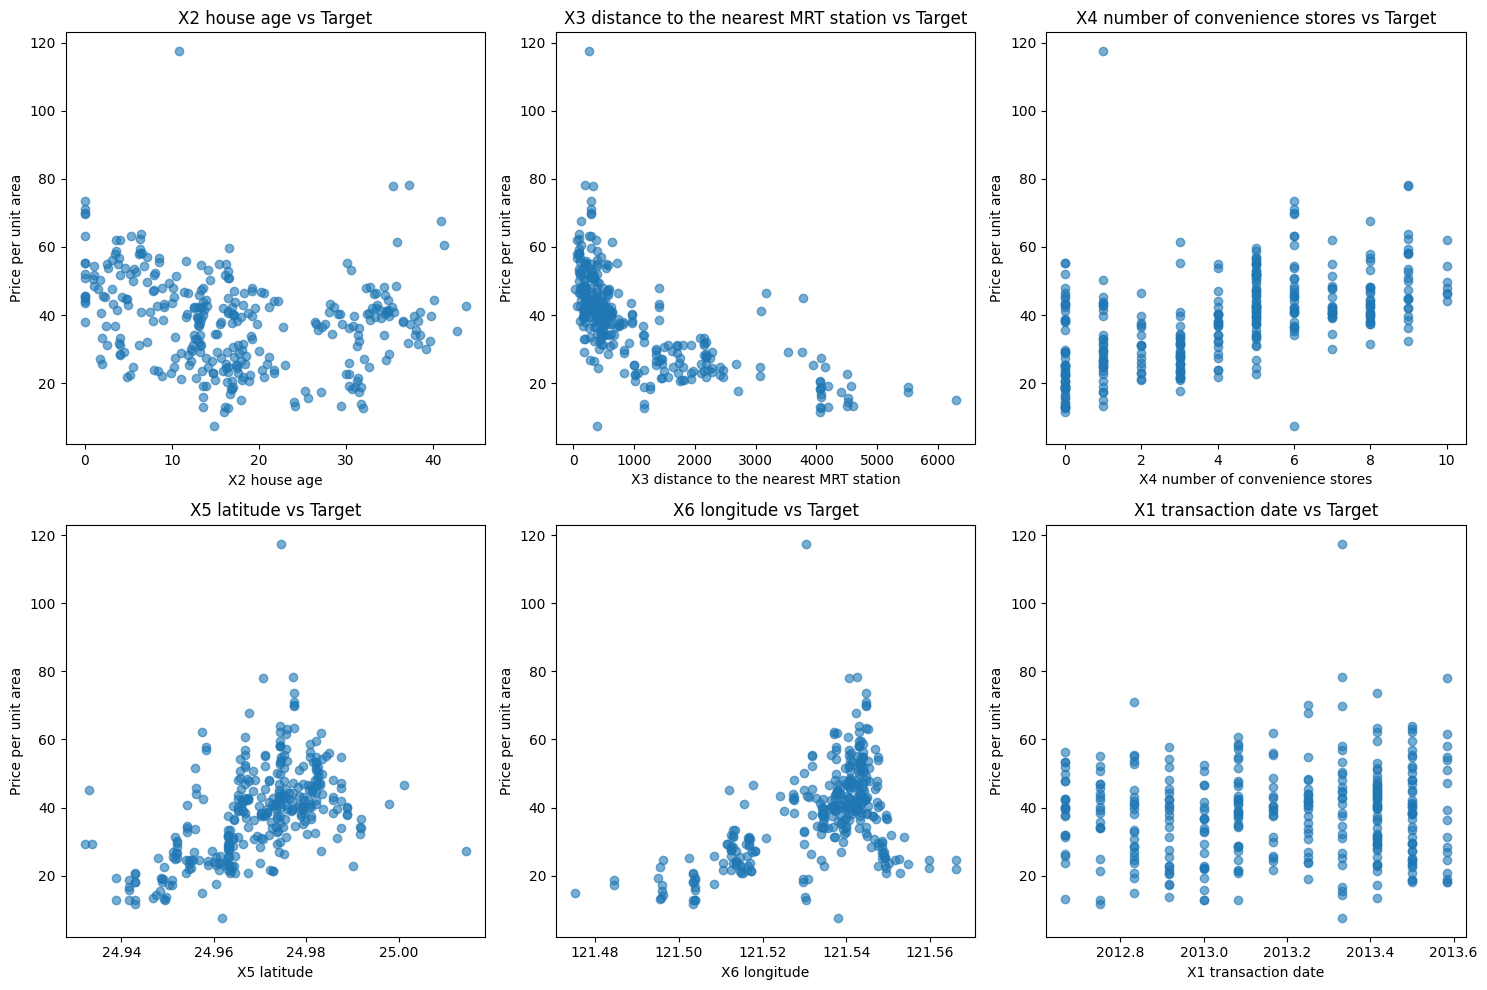

In [12]:
# Feature-Target Relationships (Scatter plots)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
feature_cols = ['X2 house age', 'X3 distance to the nearest MRT station', 
                'X4 number of convenience stores', 'X5 latitude', 
                'X6 longitude', 'X1 transaction date']

for idx, ax in enumerate(axes.flatten()):
    if idx < len(feature_cols):
        ax.scatter(train_df[feature_cols[idx]], train_df[target], alpha=0.6)
        ax.set_xlabel(feature_cols[idx])
        ax.set_ylabel('Price per unit area')
        ax.set_title(f'{feature_cols[idx]} vs Target')

plt.tight_layout()
plt.show()

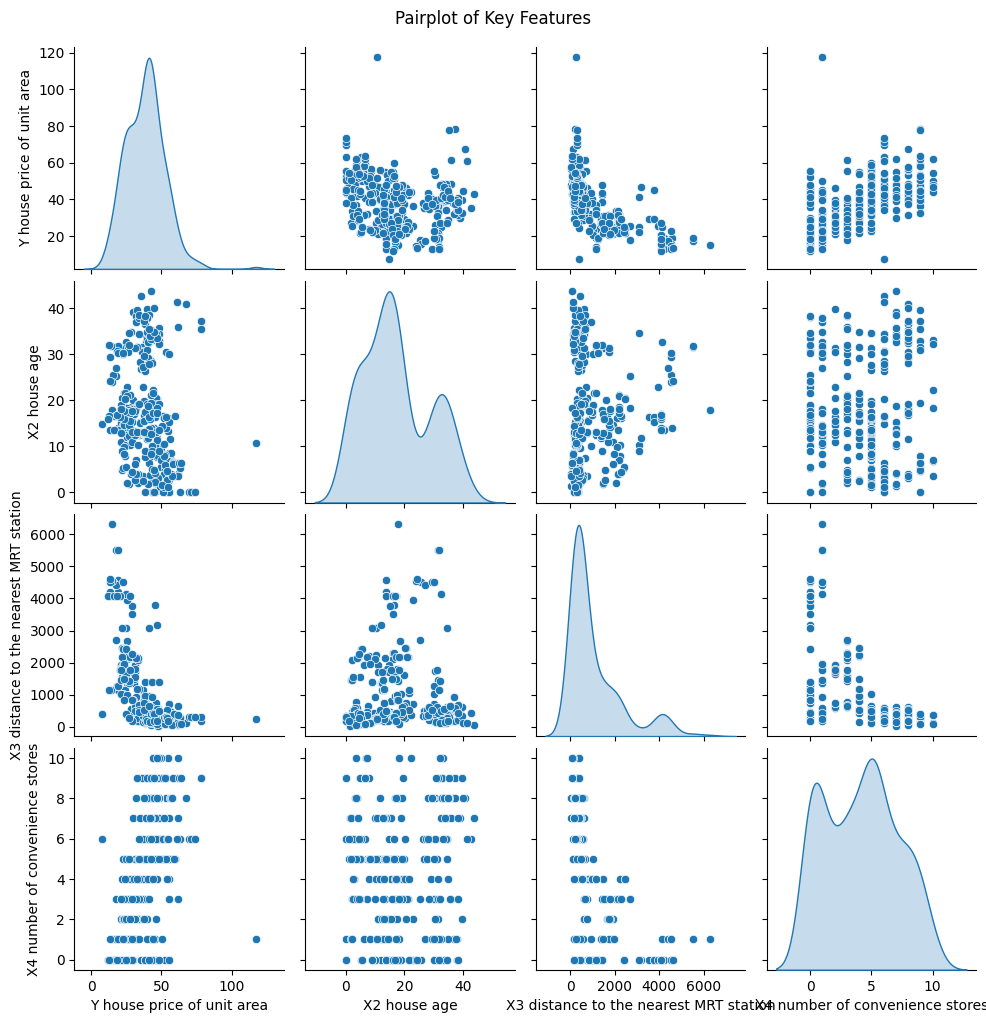

In [13]:
# Pairplot of key features (limited to avoid clutter)
key_features = [target, 'X2 house age', 'X3 distance to the nearest MRT station', 
                'X4 number of convenience stores']
if all(col in train_df.columns for col in key_features):
    sns.pairplot(train_df[key_features], diag_kind='kde')
    plt.suptitle('Pairplot of Key Features', y=1.02)
    plt.show()

In [16]:
# EDA Observations
print("\nEDA OBSERVATIONS")
print("Target variable (Price per unit area):")
print(f"   - Range: {train_df[target].min():.2f} to {train_df[target].max():.2f} (10,000 NTD/Ping)")
print(f"   - Mean: {train_df[target].mean():.2f}, Median: {train_df[target].median():.2f}")
print(f"   - Skewness: {train_df[target].skew():.3f} (moderately right-skewed)")


EDA OBSERVATIONS
Target variable (Price per unit area):
   - Range: 7.60 to 117.50 (10,000 NTD/Ping)
   - Mean: 38.39, Median: 39.30
   - Skewness: 0.713 (moderately right-skewed)


### Step 5: Data Preprocessing pipeline

In [17]:
print("\nDATA PREPROCESSING")

# Identify numeric and categorical features
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# For UCI dataset, all features are numeric, so we'll use numeric pipeline
# Create preprocessing pipeline
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical features (if any)
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create column transformer
preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
], remainder='drop')

# Test the preprocessor
X_transformed = preprocess.fit_transform(X_train)
print(f"Preprocessed training data shape: {X_transformed.shape}")
print(f"Number of features after preprocessing: {X_transformed.shape[1]}")


DATA PREPROCESSING
Numeric features: ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
Categorical features: []
Preprocessed training data shape: (331, 6)
Number of features after preprocessing: 6


### Step 6: Naive Baseline

In [18]:
print("\nNAIVE BASELINE")

naive = DummyRegressor(strategy='mean')
naive.fit(X_train[numeric_features], y_train)
naive_pred = naive.predict(X_test[numeric_features])

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print(f"Naive (Mean) MAE: {naive_mae:.4f}")
print(f"Naive (Mean) RMSE: {naive_rmse:.4f}")


NAIVE BASELINE
Naive (Mean) MAE: 10.9167
Naive (Mean) RMSE: 13.1137


### Step 7: Simple Linear Regression


Simple Linear Regression
Feature selected: X3 distance to the nearest MRT station
Intercept: 46.2427
Slope: -0.0074
Interpretation: For each unit increase in distance to MRT, price decreases by 0.0074 units


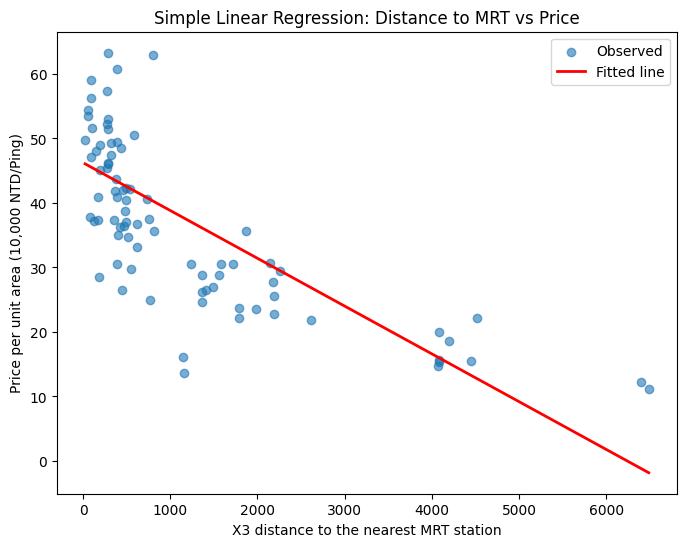

Simple Linear Regression Metrics:
MAE: 6.9210
RMSE: 8.7945
R²: 0.5390


In [19]:
print("\nSimple Linear Regression")

# Select the most informative feature based on correlation
# From correlation analysis, 'X3 distance to the nearest MRT station' has the strongest correlation
simple_feature = 'X3 distance to the nearest MRT station'

simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)
simple_pred = simple_model.predict(X_test[[simple_feature]])

print(f"Feature selected: {simple_feature}")
print(f"Intercept: {simple_model.intercept_:.4f}")
print(f"Slope: {simple_model.coef_[0]:.4f}")
print(f"Interpretation: For each unit increase in distance to MRT, price decreases by {abs(simple_model.coef_[0]):.4f} units")

# Simple Regression Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_test[simple_feature], y_test, alpha=0.6, label='Observed')
order = np.argsort(X_test[simple_feature].to_numpy())
ax.plot(
    X_test[simple_feature].to_numpy()[order],
    simple_pred[order],
    linewidth=2, color='red', label='Fitted line'
)
ax.set_xlabel(simple_feature)
ax.set_ylabel('Price per unit area (10,000 NTD/Ping)')
ax.set_title('Simple Linear Regression: Distance to MRT vs Price')
ax.legend()
plt.show()

# Simple Linear Regression Metrics
simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
simple_r2 = r2_score(y_test, simple_pred)

print(f"Simple Linear Regression Metrics:")
print(f"MAE: {simple_mae:.4f}")
print(f"RMSE: {simple_rmse:.4f}")
print(f"R²: {simple_r2:.4f}")

### Step 8: Evaluation Function

In [20]:
def evaluate_regressor(name, fitted_pipeline, X_eval, y_eval, X_train_eval=None, y_train_eval=None):
    """
    Evaluate a regression model with comprehensive metrics.
    """
    pred = fitted_pipeline.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    mse = mean_squared_error(y_eval, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, pred)
    
    # Calculate adjusted R²
    # Get transformed features to determine p
    try:
        Xt = fitted_pipeline.named_steps['preprocess'].transform(X_eval)
        n, p = Xt.shape
        adj_r2 = np.nan if n <= p + 1 else 1 - (1 - r2) * (n - 1) / (n - p - 1)
    except:
        adj_r2 = np.nan
    
    # Training metrics if provided
    train_mae = None
    train_rmse = None
    train_r2 = None
    if X_train_eval is not None and y_train_eval is not None:
        train_pred = fitted_pipeline.predict(X_train_eval)
        train_mae = mean_absolute_error(y_train_eval, train_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train_eval, train_pred))
        train_r2 = r2_score(y_train_eval, train_pred)
    
    return {
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted R2': adj_r2,
        'Train_MAE': train_mae,
        'Train_RMSE': train_rmse,
        'Train_R2': train_r2
    }, pred

### Step 9: Models Building

In [31]:
print("\nModel Building :")

# 1. Simple Linear Regression
simple_feature = 'X3 distance to the nearest MRT station'

simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)
simple_pred = simple_model.predict(X_test[[simple_feature]])

print(f"  Simple Linear Regression built with feature: {simple_feature}")
print(f"  Intercept: {simple_model.intercept_:.4f}")
print(f"  Slope: {simple_model.coef_[0]:.4f}")

# 2. Multiple Linear Regression (with preprocessing pipeline)
linear_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])
linear_pipeline.fit(X_train, y_train)
linear_pred = linear_pipeline.predict(X_test)

print("  Multiple Linear Regression built with preprocessing pipeline")

# 3. Ridge Regression (Regularized Linear Model)
ridge_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)

print("  Ridge Regression built (alpha=1.0)")

# 4. Lasso Regression (L1 Regularization)
lasso_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', Lasso(alpha=0.001, max_iter=20000))
])
lasso_pipeline.fit(X_train, y_train)
lasso_pred = lasso_pipeline.predict(X_test)

print("  Lasso Regression built (alpha=0.001)")

# 5. Elastic Net (Combined L1 and L2 Regularization)
elastic_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000))
])
elastic_pipeline.fit(X_train, y_train)
elastic_pred = elastic_pipeline.predict(X_test)

print("  Elastic Net built (alpha=0.001, l1_ratio=0.5)")

# 6. Decision Tree Regressor
dt_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeRegressor(max_depth=4, random_state=SEED))
])
dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)

print("  Decision Tree built (max_depth=6)")

# 7. Random Forest Regressor
rf_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=100, 
        min_samples_leaf=2,
        max_depth=4,
        random_state=SEED, 
        n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("  Random Forest built (n_estimators=300, min_samples_leaf=2)")

# 8. Gradient Boosting Regressor
gb_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', GradientBoostingRegressor(random_state=SEED))
])
gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

print("  Gradient Boosting built (default parameters)")

# 9. XGBoost Regressor
xgb_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=SEED,
        n_jobs=-1
    ))
])
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

print("  XGBoost built (n_estimators=500, learning_rate=0.03, max_depth=4)")

# 10. Polynomial Regression (Degree 2 with Ridge Regularization)
selected_numeric = ['X2 house age', 'X3 distance to the nearest MRT station', 
                    'X4 number of convenience stores']

poly_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

poly_pipe.fit(X_train[selected_numeric], y_train)
poly_pred = poly_pipe.predict(X_test[selected_numeric])

print("  Polynomial Regression built (degree=2 with Ridge)")

# Store all models and predictions for evaluation
all_models = {
    'Simple Linear Regression': (simple_model, simple_pred),
    'Multiple Linear Regression': (linear_pipeline, linear_pred),
    'Ridge Regression': (ridge_pipeline, ridge_pred),
    'Lasso Regression': (lasso_pipeline, lasso_pred),
    'Elastic Net': (elastic_pipeline, elastic_pred),
    'Decision Tree': (dt_pipeline, dt_pred),
    'Random Forest': (rf_pipeline, rf_pred),
    'Gradient Boosting': (gb_pipeline, gb_pred),
    'XGBoost': (xgb_pipeline, xgb_pred),
    'Polynomial Regression': (poly_pipe, poly_pred)
}

# Store pipelines for cross-validation and tuning
model_pipelines = {
    'Linear Regression': linear_pipeline,
    'Ridge': ridge_pipeline,
    'Lasso': lasso_pipeline,
    'Elastic Net': elastic_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline,
    'XGBoost': xgb_pipeline
}

print("\n All models built successfully!")


Model Building :
  Simple Linear Regression built with feature: X3 distance to the nearest MRT station
  Intercept: 46.2427
  Slope: -0.0074
  Multiple Linear Regression built with preprocessing pipeline
  Ridge Regression built (alpha=1.0)
  Lasso Regression built (alpha=0.001)
  Elastic Net built (alpha=0.001, l1_ratio=0.5)
  Decision Tree built (max_depth=6)
  Random Forest built (n_estimators=300, min_samples_leaf=2)
  Gradient Boosting built (default parameters)
  XGBoost built (n_estimators=500, learning_rate=0.03, max_depth=4)
  Polynomial Regression built (degree=2 with Ridge)

 All models built successfully!


### Step 10: Evaluation and Performance Comparison

In [32]:
def evaluate_model_performance(model_name, y_pred, y_test, y_train=None, X_train_data=None, model=None):
    """
    Comprehensive evaluation function for model performance metrics.
    """
    # Calculate test metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    # Calculate training metrics if data provided
    train_mae = None
    train_rmse = None
    train_r2 = None
    
    if y_train is not None and X_train_data is not None and model is not None:
        try:
            train_pred = model.predict(X_train_data)
            train_mae = mean_absolute_error(y_train, train_pred)
            train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
            train_r2 = r2_score(y_train, train_pred)
        except:
            pass
    
    return {
        'Model': model_name,
        'Test_MAE': mae,
        'Test_RMSE': rmse,
        'Test_R2': r2,
        'Test_MSE': mse,
        'MAPE_%': mape,
        'Train_MAE': train_mae,
        'Train_RMSE': train_rmse,
        'Train_R2': train_r2
    }

# Evaluate all models
evaluation_results = []

print("\nEvaluating all models on test set...\n")

for model_name, (model, pred) in all_models.items():
    # For polynomial regression, we use different X_train
    if model_name == 'Polynomial Regression':
        train_pred_available = False
        train_mae_val = None
        train_rmse_val = None
        train_r2_val = None
    else:
        try:
            if hasattr(model, 'predict'):
                train_pred = model.predict(X_train)
                train_mae_val = mean_absolute_error(y_train, train_pred)
                train_rmse_val = np.sqrt(mean_squared_error(y_train, train_pred))
                train_r2_val = r2_score(y_train, train_pred)
            else:
                train_mae_val = None
                train_rmse_val = None
                train_r2_val = None
        except:
            train_mae_val = None
            train_rmse_val = None
            train_r2_val = None
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test.values - pred) / y_test.values)) * 100
    
    evaluation_results.append({
        'Model': model_name,
        'Test_MAE': mae,
        'Test_RMSE': rmse,
        'Test_R2': r2,
        'Test_MSE': mse,
        'MAPE_%': mape,
        'Train_MAE': train_mae_val,
        'Train_RMSE': train_rmse_val,
        'Train_R2': train_r2_val
    })

# Convert to DataFrame and sort
eval_df = pd.DataFrame(evaluation_results)
eval_df = eval_df.sort_values('Test_RMSE')

print("\n MODEL PERFORMANCE SUMMARY (Sorted by RMSE)")
display(eval_df.round(4))


Evaluating all models on test set...


 MODEL PERFORMANCE SUMMARY (Sorted by RMSE)


,Model,Test_MAE,Test_RMSE,Test_R2,Test_MSE,MAPE_%,Train_MAE,Train_RMSE,Train_R2
8,XGBoost,3.7615,5.5327,0.8175,30.6110,12.3136,3.4306,4.8544,0.8747
7,Gradient Boosting,3.9036,5.8443,0.7964,34.1556,11.9562,2.6921,3.6284,0.9300
6,Random Forest,4.2806,5.9220,0.7910,35.0700,13.6386,4.3557,6.3443,0.7860
5,Decision Tree,4.7395,6.2470,0.7674,39.0252,14.6770,4.6826,6.3676,0.7844
9,Polynomial Regression,4.9593,6.8856,0.7174,47.4120,16.4855,NaN,NaN,NaN
2,Ridge Regression,5.3022,7.3108,0.6814,53.4485,17.1469,6.3404,9.1167,0.5581
4,Elastic Net,5.3048,7.3139,0.6811,53.4937,17.1762,6.3399,9.1167,0.5581
3,Lasso Regression,5.3052,7.3144,0.6811,53.5004,17.1812,6.3398,9.1167,0.5581
1,Multiple Linear Regression,5.3054,7.3148,0.6811,53.5056,17.1825,6.3397,9.1167,0.5581
0,Simple Linear Regression,6.9210,8.7945,0.5390,77.3440,23.9020,NaN,NaN,NaN


In [33]:
# Cross validation for all models
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv_results_list = []

for name, pipeline in model_pipelines.items():
    print(f"  Cross-validating {name}...")
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results_list.append({
        'Model': name,
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_MAE_std': scores['test_mae'].std(),
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_RMSE_std': scores['test_rmse'].std(),
        'CV_R2_mean': scores['test_r2'].mean(),
        'CV_R2_std': scores['test_r2'].std(),
        'Fit_Time_mean': scores['fit_time'].mean()
    })

cv_df = pd.DataFrame(cv_results_list).sort_values('CV_RMSE_mean')

print("\n=== CROSS-VALIDATION RESULTS (5-fold) ===")
display(cv_df.round(4))


  Cross-validating Linear Regression...
  Cross-validating Ridge...
  Cross-validating Lasso...
  Cross-validating Elastic Net...
  Cross-validating Decision Tree...
  Cross-validating Random Forest...
  Cross-validating Gradient Boosting...
  Cross-validating XGBoost...

=== CROSS-VALIDATION RESULTS (5-fold) ===


,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,Fit_Time_mean
7,XGBoost,5.1093,0.6203,7.7122,2.0579,0.6758,0.0833,0.1485
5,Random Forest,5.2242,0.7384,7.7845,2.2666,0.6670,0.1076,0.7539
6,Gradient Boosting,5.4448,0.3847,8.3502,1.8180,0.6195,0.0640,0.5060
1,Ridge,6.5455,0.7812,9.1083,2.2552,0.5481,0.0998,0.0295
3,Elastic Net,6.5455,0.7801,9.1105,2.2522,0.5478,0.0997,0.0269
2,Lasso,6.5455,0.7800,9.1108,2.2518,0.5478,0.0997,0.0313
0,Linear Regression,6.5453,0.7798,9.1109,2.2517,0.5478,0.0997,0.0350
4,Decision Tree,6.1188,0.5777,9.5809,2.2622,0.4958,0.1319,0.0292


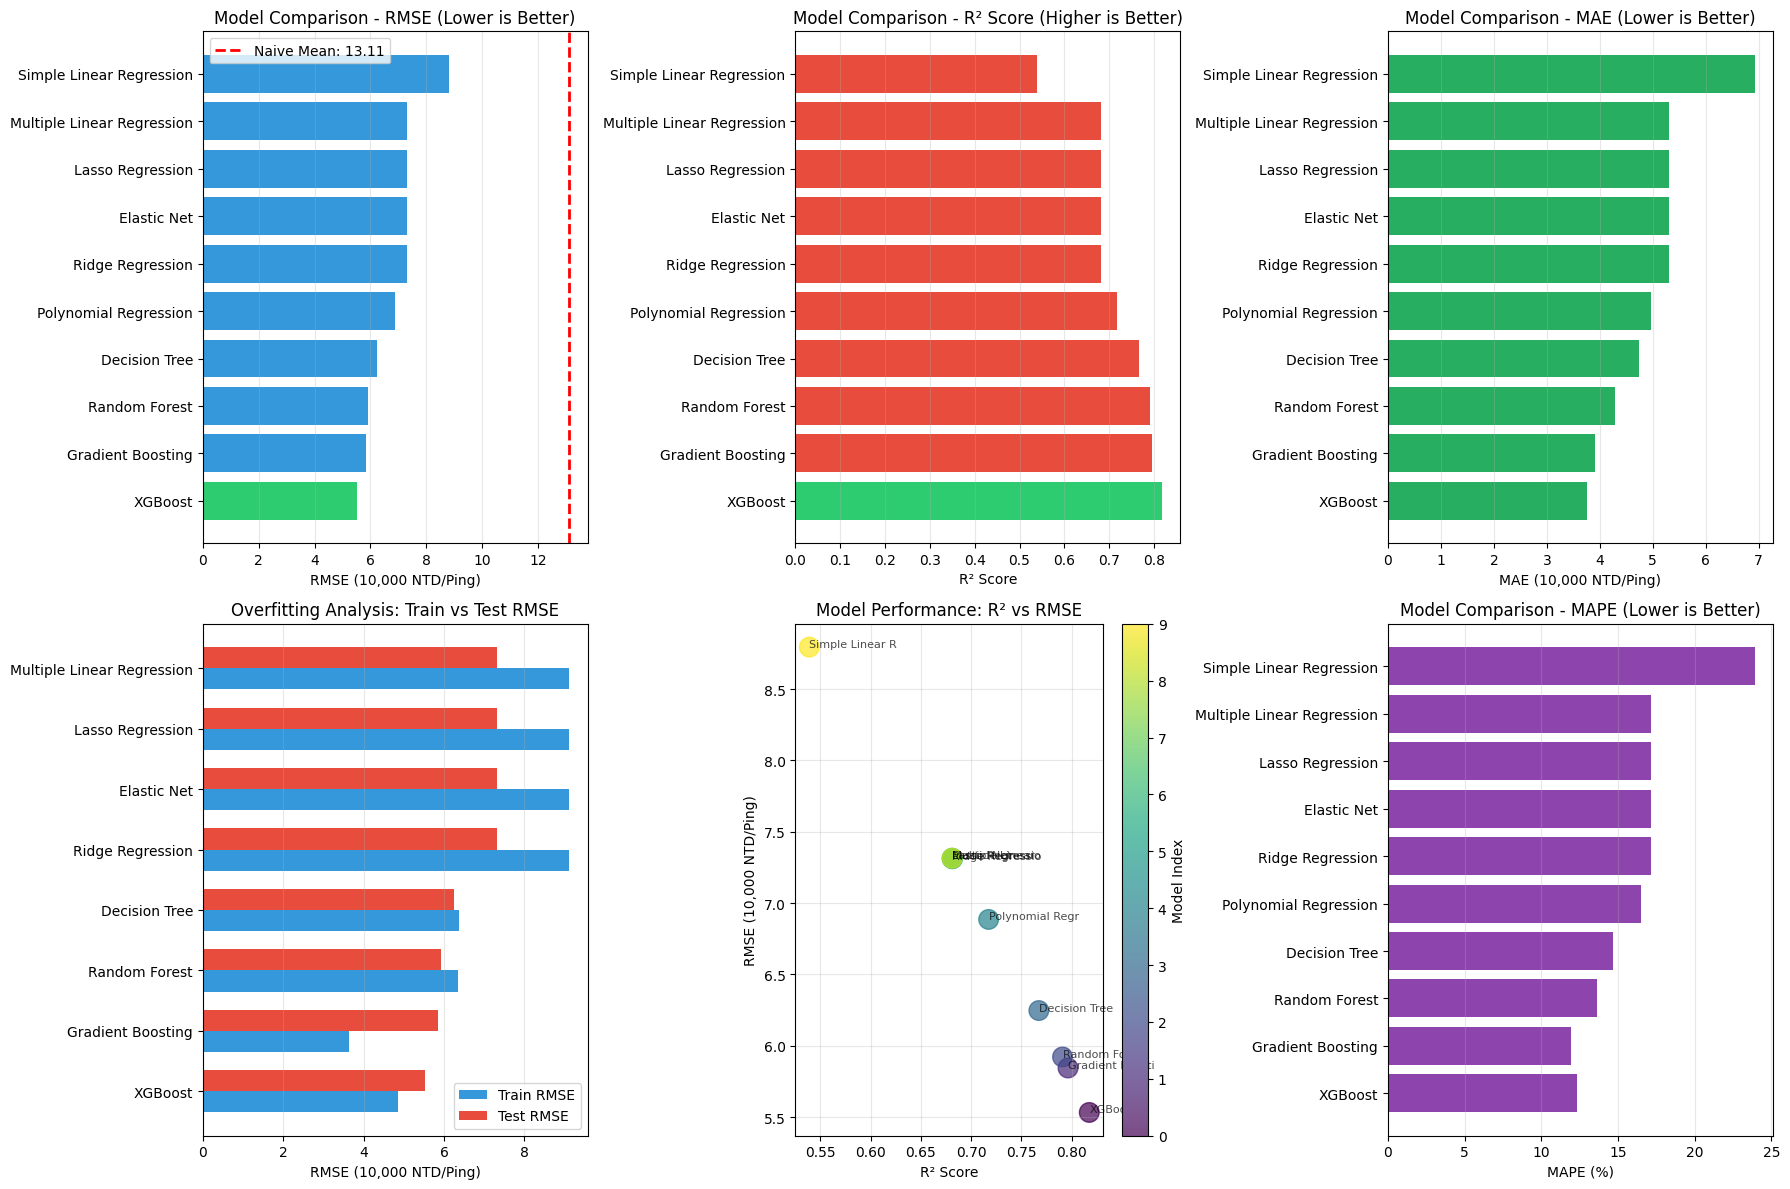

In [34]:
# Visualizing the models' performance 
# Create a figure with multiple subplots
fig = plt.figure(figsize=(18, 12))

# 1. RMSE Comparison Bar Chart
ax1 = plt.subplot(2, 3, 1)
models_sorted = eval_df['Model'].tolist()
rmse_sorted = eval_df['Test_RMSE'].tolist()
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(rmse_sorted))]
bars = ax1.barh(models_sorted, rmse_sorted, color=colors)
ax1.axvline(x=naive_rmse, color='red', linestyle='--', linewidth=2, label=f'Naive Mean: {naive_rmse:.2f}')
ax1.set_xlabel('RMSE (10,000 NTD/Ping)')
ax1.set_title('Model Comparison - RMSE (Lower is Better)')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. R² Score Bar Chart
ax2 = plt.subplot(2, 3, 2)
r2_sorted = eval_df['Test_R2'].tolist()
colors_r2 = ['#2ecc71' if i == max(r2_sorted) else '#e74c3c' for i in r2_sorted]
bars2 = ax2.barh(models_sorted, r2_sorted, color=colors_r2)
ax2.set_xlabel('R² Score')
ax2.set_title('Model Comparison - R² Score (Higher is Better)')
ax2.grid(axis='x', alpha=0.3)

# 3. MAE Comparison Bar Chart
ax3 = plt.subplot(2, 3, 3)
mae_sorted = eval_df['Test_MAE'].tolist()
bars3 = ax3.barh(models_sorted, mae_sorted, color='#27ae60')
ax3.set_xlabel('MAE (10,000 NTD/Ping)')
ax3.set_title('Model Comparison - MAE (Lower is Better)')
ax3.grid(axis='x', alpha=0.3)

# 4. Overfitting Analysis (Train vs Test RMSE)
ax4 = plt.subplot(2, 3, 4)
valid_models = eval_df[eval_df['Train_RMSE'].notna()]
x_pos = np.arange(len(valid_models))
width = 0.35
ax4.barh(x_pos - width/2, valid_models['Train_RMSE'].tolist(), width, label='Train RMSE', color='#3498db')
ax4.barh(x_pos + width/2, valid_models['Test_RMSE'].tolist(), width, label='Test RMSE', color='#e74c3c')
ax4.set_yticks(x_pos)
ax4.set_yticklabels(valid_models['Model'].tolist())
ax4.set_xlabel('RMSE (10,000 NTD/Ping)')
ax4.set_title('Overfitting Analysis: Train vs Test RMSE')
ax4.legend()
ax4.grid(axis='x', alpha=0.3)

# 5. Model Performance Summary (Scatter Plot)
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(eval_df['Test_R2'], eval_df['Test_RMSE'], 
                     s=200, c=range(len(eval_df)), cmap='viridis', alpha=0.7)
ax5.set_xlabel('R² Score')
ax5.set_ylabel('RMSE (10,000 NTD/Ping)')
ax5.set_title('Model Performance: R² vs RMSE')
for idx, row in eval_df.iterrows():
    ax5.annotate(row['Model'][:15], (row['Test_R2'], row['Test_RMSE']), 
                fontsize=8, alpha=0.7)
ax5.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax5, label='Model Index')

# 6. MAPE Comparison
ax6 = plt.subplot(2, 3, 6)
mape_sorted = eval_df['MAPE_%'].tolist()
bars6 = ax6.barh(models_sorted, mape_sorted, color='#8e44ad')
ax6.set_xlabel('MAPE (%)')
ax6.set_title('Model Comparison - MAPE (Lower is Better)')
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:
# Best model selection
# Find best model by RMSE
best_model_by_rmse = eval_df.loc[eval_df['Test_RMSE'].idxmin()]
best_model_by_r2 = eval_df.loc[eval_df['Test_R2'].idxmax()]

print(f"Best Model by RMSE: {best_model_by_rmse['Model']}")
print(f"  RMSE: {best_model_by_rmse['Test_RMSE']:.4f}")
print(f"  R²: {best_model_by_rmse['Test_R2']:.4f}")
print(f"  MAE: {best_model_by_rmse['Test_MAE']:.4f}")
print(f"  MAPE: {best_model_by_rmse['MAPE_%']:.2f}%")

print(f"\nBest Model by R²: {best_model_by_r2['Model']}")
print(f"  RMSE: {best_model_by_r2['Test_RMSE']:.4f}")
print(f"  R²: {best_model_by_r2['Test_R2']:.4f}")
print(f"  MAE: {best_model_by_r2['Test_MAE']:.4f}")
print(f"  MAPE: {best_model_by_r2['MAPE_%']:.2f}%")

# Identify overfitting models
print("\nOverfitting Assessment (Train vs Test RMSE):")
for idx, row in eval_df.iterrows():
    if pd.notna(row['Train_RMSE']) and pd.notna(row['Test_RMSE']):
        diff_pct = (row['Test_RMSE'] - row['Train_RMSE']) / row['Train_RMSE'] * 100
        status = "OVERFITTING" if diff_pct > 20 else "Good" if diff_pct < 10 else "Moderate"
        print(f"  {row['Model']}: Train RMSE={row['Train_RMSE']:.4f}, Test RMSE={row['Test_RMSE']:.4f}, Diff={diff_pct:.1f}% {status}")

Best Model by RMSE: XGBoost
  RMSE: 5.5327
  R²: 0.8175
  MAE: 3.7615
  MAPE: 12.31%

Best Model by R²: XGBoost
  RMSE: 5.5327
  R²: 0.8175
  MAE: 3.7615
  MAPE: 12.31%

Overfitting Assessment (Train vs Test RMSE):
  XGBoost: Train RMSE=4.8544, Test RMSE=5.5327, Diff=14.0% Moderate
  Gradient Boosting: Train RMSE=3.6284, Test RMSE=5.8443, Diff=61.1% OVERFITTING
  Random Forest: Train RMSE=6.3443, Test RMSE=5.9220, Diff=-6.7% Good
  Decision Tree: Train RMSE=6.3676, Test RMSE=6.2470, Diff=-1.9% Good
  Ridge Regression: Train RMSE=9.1167, Test RMSE=7.3108, Diff=-19.8% Good
  Elastic Net: Train RMSE=9.1167, Test RMSE=7.3139, Diff=-19.8% Good
  Lasso Regression: Train RMSE=9.1167, Test RMSE=7.3144, Diff=-19.8% Good
  Multiple Linear Regression: Train RMSE=9.1167, Test RMSE=7.3148, Diff=-19.8% Good


### Step 11: Hyperparameter tuning (Grid Search)

In [40]:
# Tuning Ridge Regression -------------------------------
ridge_tune = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge())
])

ridge_grid = {
    'model__alpha': np.logspace(-4, 4, 20)
}

search_ridge = GridSearchCV(
    ridge_tune,
    param_grid=ridge_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

search_ridge.fit(X_train, y_train)

print(f"  Best alpha: {search_ridge.best_params_['model__alpha']:.4f}")
print(f"  Best CV RMSE: {-search_ridge.best_score_:.4f}")

ridge_tuned_pred = search_ridge.best_estimator_.predict(X_test)
ridge_tuned_rmse = np.sqrt(mean_squared_error(y_test, ridge_tuned_pred))
ridge_tuned_r2 = r2_score(y_test, ridge_tuned_pred)

print(f"  Tuned Ridge Test RMSE: {ridge_tuned_rmse:.4f}")
print(f"  Tuned Ridge Test R²: {ridge_tuned_r2:.4f}")


# Tuning Random Forest -----------------------------
rf_tune = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

rf_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [6, 10, 15, None],
    'model__min_samples_leaf': [1, 2, 4]
}

search_rf = GridSearchCV(
    rf_tune,
    param_grid=rf_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,  # Using 3-fold for speed
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

search_rf.fit(X_train, y_train)

print(f"  Best parameters: {search_rf.best_params_}")
print(f"  Best CV RMSE: {-search_rf.best_score_:.4f}")

rf_tuned_pred = search_rf.best_estimator_.predict(X_test)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)

print(f"  Tuned Random Forest Test RMSE: {rf_tuned_rmse:.4f}")
print(f"  Tuned Random Forest Test R²: {rf_tuned_r2:.4f}")

# Tuning XGBoost -------------------------------
xgb_tune = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=SEED, n_jobs=-1))
])

xgb_grid = {
    'model__n_estimators': [50, 100, 300, 500],
    'model__learning_rate': [0.01, 0.03, 0.1],
    'model__max_depth': [2, 3, 4, 6],
    'model__subsample': [0.7, 0.8, 1.0]
}

search_xgb = GridSearchCV(
    xgb_tune,
    param_grid=xgb_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,  # Using 3-fold for speed
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

search_xgb.fit(X_train, y_train)

print(f"  Best parameters: {search_xgb.best_params_}")
print(f"  Best CV RMSE: {-search_xgb.best_score_:.4f}")

xgb_tuned_pred = search_xgb.best_estimator_.predict(X_test)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
xgb_tuned_r2 = r2_score(y_test, xgb_tuned_pred)

print(f"  Tuned XGBoost Test RMSE: {xgb_tuned_rmse:.4f}")
print(f"  Tuned XGBoost Test R²: {xgb_tuned_r2:.4f}")
print(f"  Best Parameters: {search_xgb.best_params_}")

  Best alpha: 11.2884
  Best CV RMSE: 9.0937
  Tuned Ridge Test RMSE: 7.2835
  Tuned Ridge Test R²: 0.6838
  Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
  Best CV RMSE: 7.6057
  Tuned Random Forest Test RMSE: 5.5174
  Tuned Random Forest Test R²: 0.8185
  Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__subsample': 0.7}
  Best CV RMSE: 7.8141
  Tuned XGBoost Test RMSE: 5.6601
  Tuned XGBoost Test R²: 0.8090
  Best Parameters: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__subsample': 0.7}



=== FINAL RESULTS WITH TUNED MODELS ===


C:\Users\apara\AppData\Local\Temp\ipykernel_6272\397377723.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results = pd.concat([eval_df, pd.DataFrame(tuned_results)], ignore_index=True)


,Model,Test_MAE,Test_RMSE,Test_R2,Test_MSE,MAPE_%,Train_MAE,Train_RMSE,Train_R2
11,Tuned Random Forest,3.7342,5.5174,0.8185,NaN,11.6080,NaN,NaN,NaN
0,XGBoost,3.7615,5.5327,0.8175,30.6110,12.3136,3.4306,4.8544,0.8747
12,Tuned XGBoost,3.8926,5.6601,0.8090,NaN,12.4684,NaN,NaN,NaN
1,Gradient Boosting,3.9036,5.8443,0.7964,34.1556,11.9562,2.6921,3.6284,0.9300
2,Random Forest,4.2806,5.9220,0.7910,35.0700,13.6386,4.3557,6.3443,0.7860
3,Decision Tree,4.7395,6.2470,0.7674,39.0252,14.6770,4.6826,6.3676,0.7844
4,Polynomial Regression,4.9593,6.8856,0.7174,47.4120,16.4855,NaN,NaN,NaN
10,Tuned Ridge,5.2969,7.2835,0.6838,NaN,16.9166,NaN,NaN,NaN
5,Ridge Regression,5.3022,7.3108,0.6814,53.4485,17.1469,6.3404,9.1167,0.5581
6,Elastic Net,5.3048,7.3139,0.6811,53.4937,17.1762,6.3399,9.1167,0.5581


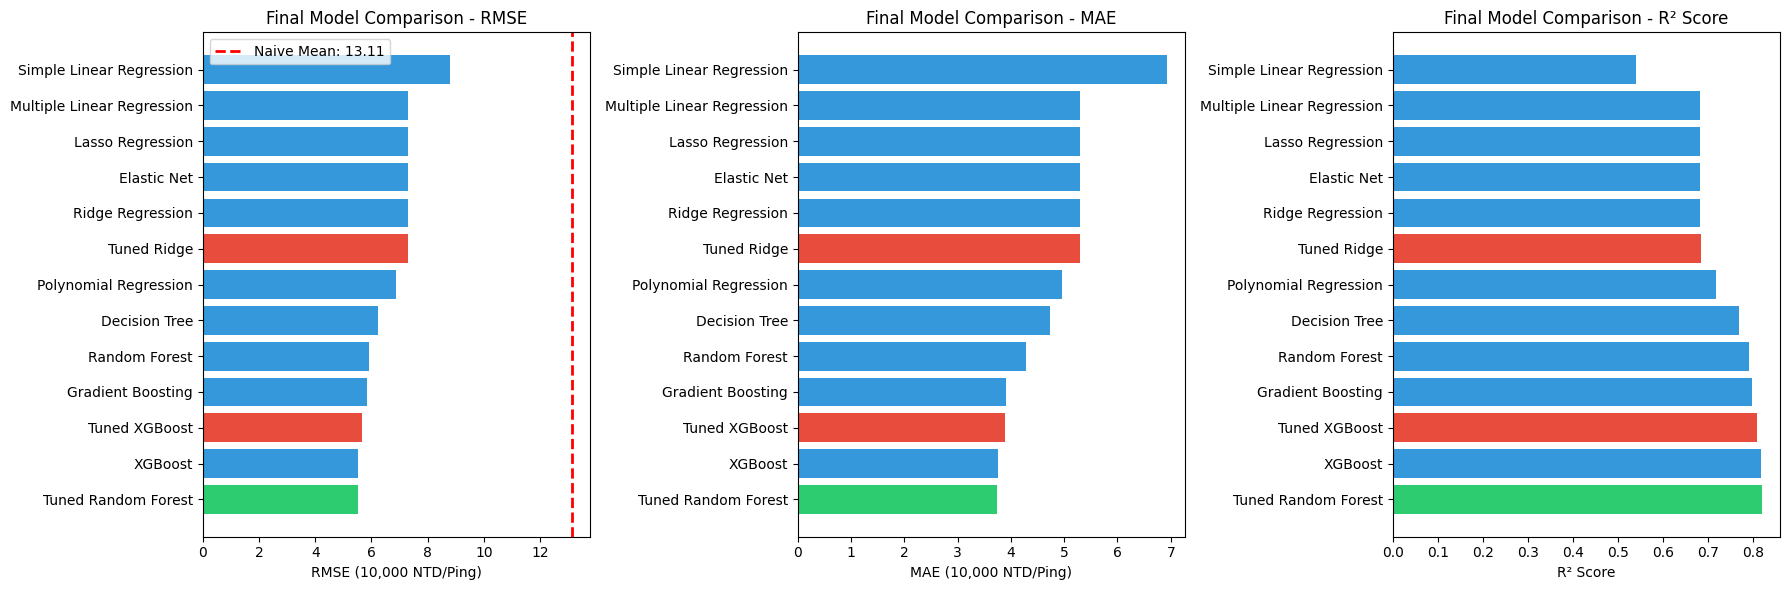

In [42]:
# Add tuned models to evaluation
tuned_results = []

tuned_models = [
    ('Tuned Ridge', search_ridge.best_estimator_, ridge_tuned_pred),
    ('Tuned Random Forest', search_rf.best_estimator_, rf_tuned_pred),
    ('Tuned XGBoost', search_xgb.best_estimator_, xgb_tuned_pred)
]

for model_name, model, pred in tuned_models:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test.values - pred) / y_test.values)) * 100
    
    tuned_results.append({
        'Model': model_name,
        'Test_MAE': mae,
        'Test_RMSE': rmse,
        'Test_R2': r2,
        'MAPE_%': mape,
        'Train_MAE': None,
        'Train_RMSE': None,
        'Train_R2': None
    })

# Combine with existing results
all_results = pd.concat([eval_df, pd.DataFrame(tuned_results)], ignore_index=True)
all_results = all_results.sort_values('Test_RMSE')

print("\n=== FINAL RESULTS WITH TUNED MODELS ===")
display(all_results.round(4))

# Tuned Model Performance Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE Comparison
ax1 = axes[0]
models = all_results['Model'].tolist()
rmse_values = all_results['Test_RMSE'].tolist()
colors = ['#2ecc71' if i == 0 else '#e74c3c' if 'Tuned' in models[i] else '#3498db' for i in range(len(rmse_values))]
ax1.barh(models, rmse_values, color=colors)
ax1.set_xlabel('RMSE (10,000 NTD/Ping)')
ax1.set_title('Final Model Comparison - RMSE')
ax1.axvline(x=naive_rmse, color='red', linestyle='--', linewidth=2, label=f'Naive Mean: {naive_rmse:.2f}')
ax1.legend()

# R² Comparison
ax2 = axes[2]
r2_values = all_results['Test_R2'].tolist()
colors_r2 = ['#2ecc71' if i == r2_values.index(max(r2_values)) else '#e74c3c' if 'Tuned' in models[i] else '#3498db' for i in range(len(r2_values))]
ax2.barh(models, r2_values, color=colors_r2)
ax2.set_xlabel('R² Score')
ax2.set_title('Final Model Comparison - R² Score')

# MAE Comparison
ax3 = axes[1]
mae_values = all_results['Test_MAE'].tolist()
colors_mae = ['#2ecc71' if i == mae_values.index(min(mae_values)) else '#e74c3c' if 'Tuned' in models[i] else '#3498db' for i in range(len(mae_values))]
ax3.barh(models, mae_values, color=colors_mae)
ax3.set_xlabel('MAE (10,000 NTD/Ping)')
ax3.set_title('Final Model Comparison - MAE')

plt.tight_layout()
plt.show()

In [43]:
# Choosing best model
best_tuned = all_results.iloc[0]
print(f"Best Overall Model: {best_tuned['Model']}")
print(f"  Test RMSE: {best_tuned['Test_RMSE']:.4f}")
print(f"  Test R²: {best_tuned['Test_R2']:.4f}")
print(f"  Test MAE: {best_tuned['Test_MAE']:.4f}")
print(f"  MAPE: {best_tuned['MAPE_%']:.2f}%")

# Store the best tuned model for saving
if 'Tuned Ridge' in best_tuned['Model']:
    final_best_model = search_ridge.best_estimator_
elif 'Tuned Random Forest' in best_tuned['Model']:
    final_best_model = search_rf.best_estimator_
elif 'Tuned XGBoost' in best_tuned['Model']:
    final_best_model = search_xgb.best_estimator_
else:
    # Get the best performing model from all_models
    best_model_name = best_tuned['Model']
    if best_model_name in all_models:
        final_best_model = all_models[best_model_name][0]

print(f"\nFinal Best Model: {best_tuned['Model']}")

Best Overall Model: Tuned Random Forest
  Test RMSE: 5.5174
  Test R²: 0.8185
  Test MAE: 3.7342
  MAPE: 11.61%

Final Best Model: Tuned Random Forest


### Step 12: Saving results and artifacts

In [50]:
os.makedirs('artifacts', exist_ok=True)

# Save all results
all_results.to_csv('uci_all_model_results.csv', index=False)
cv_df.to_csv('uci_cv_results.csv', index=False)
eval_df.to_csv('uci_evaluation_results.csv', index=False)

print("  Results saved as CSV files")


# Save all trained models
model_save_paths = {}

for model_name, (model, pred) in all_models.items():
    # Clean filename
    filename = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    filepath = f'artifacts/uci_{filename}.joblib'
    try:
        joblib.dump(model, filepath)
        model_save_paths[model_name] = filepath
        print(f"  Saved: {model_name} -> {filepath}")
    except Exception as e:
        print(f"  Failed to save {model_name}: {e}")

# Save tuned models
tuned_models = {
    'Tuned_Ridge': search_ridge.best_estimator_,
    'Tuned_Random_Forest': search_rf.best_estimator_,
    'Tuned_XGBoost': search_xgb.best_estimator_
}

for model_name, model in tuned_models.items():
    filepath = f'artifacts/uci_{model_name}.joblib'
    try:
        joblib.dump(model, filepath)
        model_save_paths[model_name] = filepath
        print(f"  Saved: {model_name} -> {filepath}")
    except Exception as e:
        print(f"  Failed to save {model_name}: {e}")

# Save the best model separately with a standard name
best_model_path = 'artifacts/uci_best_model.joblib'
joblib.dump(final_best_model, best_model_path)
print(f"  Best model saved as '{best_model_path}'")

# Save the preprocessing pipeline separately (useful for deployment)
preprocess_path = 'artifacts/uci_preprocessing_pipeline.joblib'
joblib.dump(preprocess, preprocess_path)
print(f"  Preprocessing pipeline saved as '{preprocess_path}'")

# Save Model Metadata
# Create comprehensive model registry
model_registry = {
    'best_model': {
        'name': best_tuned['Model'],
        'file': 'best_model.joblib',
        'metrics': {
            'RMSE': float(best_tuned['Test_RMSE']),
            'R2': float(best_tuned['Test_R2']),
            'MAE': float(best_tuned['Test_MAE']),
            'MAPE': float(best_tuned['MAPE_%'])
        }
    },
    'all_models': model_save_paths,
    'tuned_models': {
        'Ridge': {'alpha': float(search_ridge.best_params_['model__alpha']), 'file': 'Tuned_Ridge.joblib'},
        'Random_Forest': {
            'params': search_rf.best_params_,
            'file': 'Tuned_Random_Forest.joblib'
        },
        'XGBoost': {
            'params': search_xgb.best_params_,
            'file': 'Tuned_XGBoost.joblib'
        }
    },
    'preprocessing_pipeline': 'preprocessing_pipeline.joblib'
}

# Save registry
with open('artifacts/uci_model_registry.json', 'w') as f:
    json.dump(model_registry, f, indent=2)
print("  Model registry saved as 'artifacts/model_registry.json'")

# Save Training Metadata

final_metadata = {
    'dataset': 'UCI Real Estate Valuation (ID 477)',
    'dataset_info': {
        'total_samples': len(df),
        'n_features': X.shape[1],
        'target': target,
        'target_unit': '10,000 NTD/Ping'
    },
    'split_info': {
        'train_size': len(X_train),
        'test_size': len(X_test),
        'random_seed': SEED,
        'test_split': 0.20
    },
    'best_model': {
        'name': best_tuned['Model'],
        'file': 'best_model.joblib',
        'performance': {
            'RMSE': float(best_tuned['Test_RMSE']),
            'R2': float(best_tuned['Test_R2']),
            'MAE': float(best_tuned['Test_MAE']),
            'MAPE': float(best_tuned['MAPE_%'])
        }
    },
    'environment': {
        'python_version': platform.python_version(),
        'numpy_version': np.__version__,
        'pandas_version': pd.__version__,
        'sklearn_version': sklearn.__version__,
        'matplotlib_version': plt.matplotlib.__version__,
        'seaborn_version': sns.__version__
    },
    'features': X.columns.tolist(),
    'cross_validation': {
        'folds': 5,
        'cv_results_file': 'uci_cv_results.csv'
    }
}

with open('artifacts/uci_training_metadata.json', 'w') as f:
    json.dump(final_metadata, f, indent=2)
print("  Training metadata saved as 'artifacts/training_metadata.json'")

  Results saved as CSV files
  Saved: Simple Linear Regression -> artifacts/uci_simple_linear_regression.joblib
  Saved: Multiple Linear Regression -> artifacts/uci_multiple_linear_regression.joblib
  Saved: Ridge Regression -> artifacts/uci_ridge_regression.joblib
  Saved: Lasso Regression -> artifacts/uci_lasso_regression.joblib
  Saved: Elastic Net -> artifacts/uci_elastic_net.joblib
  Saved: Decision Tree -> artifacts/uci_decision_tree.joblib
  Saved: Random Forest -> artifacts/uci_random_forest.joblib
  Saved: Gradient Boosting -> artifacts/uci_gradient_boosting.joblib
  Saved: XGBoost -> artifacts/uci_xgboost.joblib
  Saved: Polynomial Regression -> artifacts/uci_polynomial_regression.joblib
  Saved: Tuned_Ridge -> artifacts/uci_Tuned_Ridge.joblib
  Saved: Tuned_Random_Forest -> artifacts/uci_Tuned_Random_Forest.joblib
  Saved: Tuned_XGBoost -> artifacts/uci_Tuned_XGBoost.joblib
  Best model saved as 'artifacts/uci_best_model.joblib'
  Preprocessing pipeline saved as 'artifacts/u